### Про T-test, ЦПТ и MDE 

Исходный файл здесь: https://github.com/avito-tech/applied_statistics/blob/main/T-test.ipynb

In [1]:
import numpy as np 
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
import random

plt.rcParams['figure.dpi'] = 150

In [2]:
# T-test

n = 7
X = np.array([6.9, 6.45, 6.32, 6.88, 6.09, 7.13, 6.76])

t = np.sqrt(n) * (X.mean() - 7) / np.sqrt(X.var(ddof=1))
pval = stats.norm(loc=0, scale=1).pdf(t)

print(f"T = {t}, pval = {pval}")

T = -2.524793468045073, pval = 0.016469755808472163


Будем много раз считать статистику, чтобы проверить ЦПТ

In [4]:
def stat_distribution(n_iter, t_func, n_sample, sample_distribution):
    res = []
    for _ in range(n_iter):
        sample = sample_distribution.rvs(n_sample)
        
        t = t_func(sample)

        res.append(t)
    
    return res

Для небольших выборок (у нас n_sample=7) Стьюдент апроксимирует более точно, чем нормальное распределение

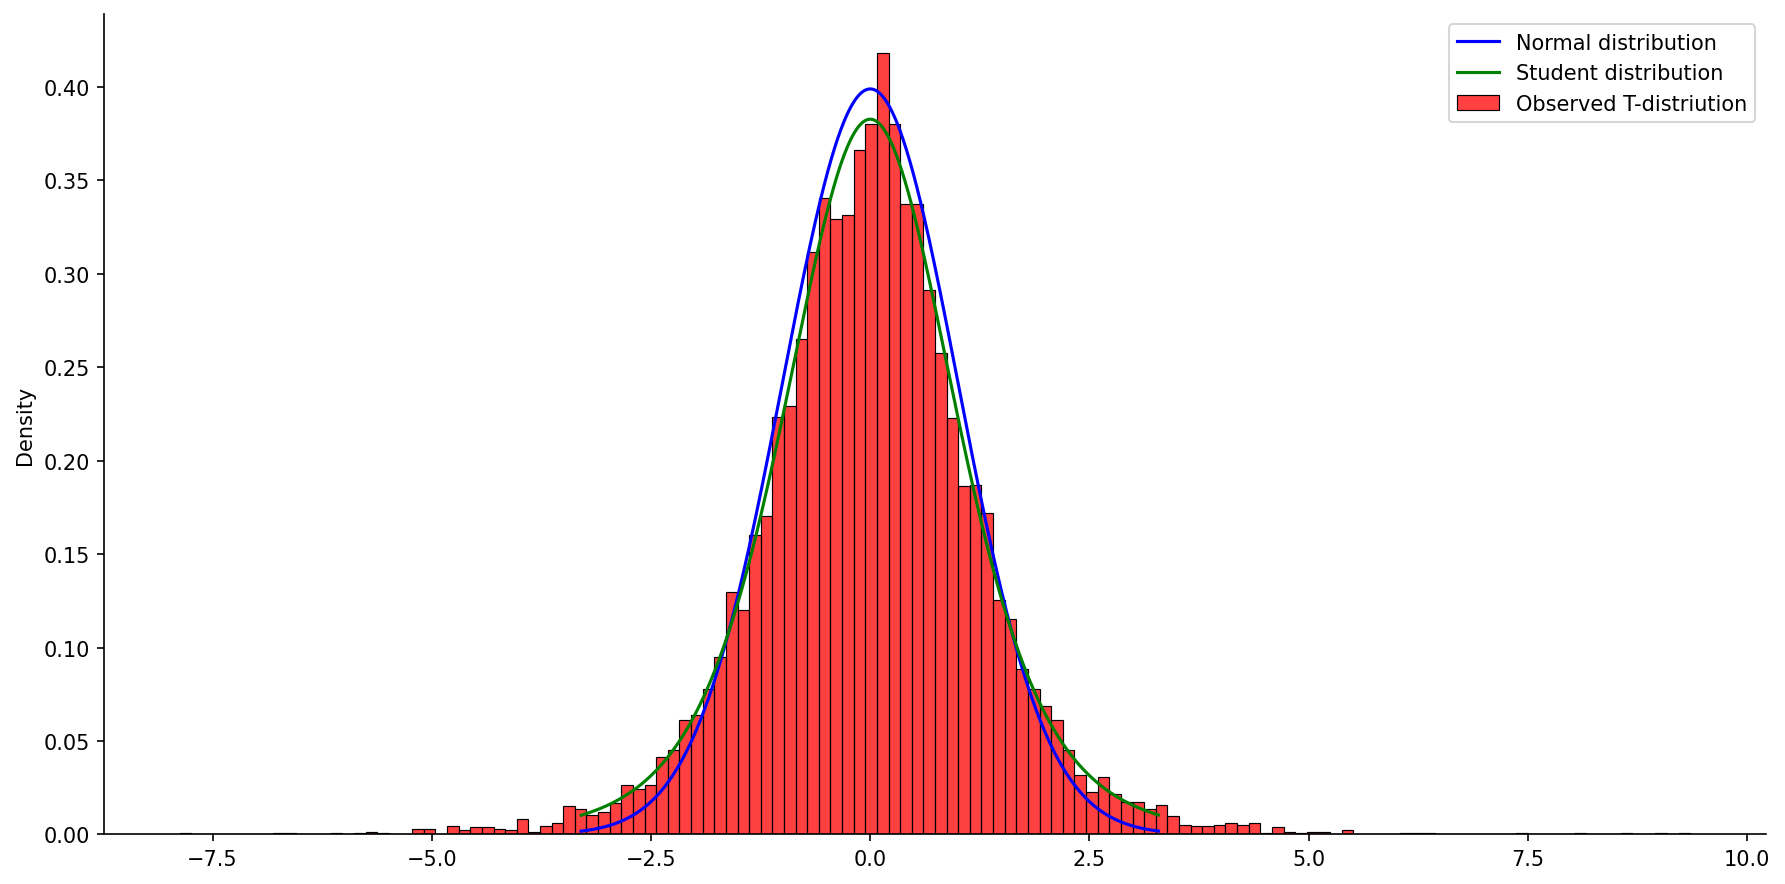

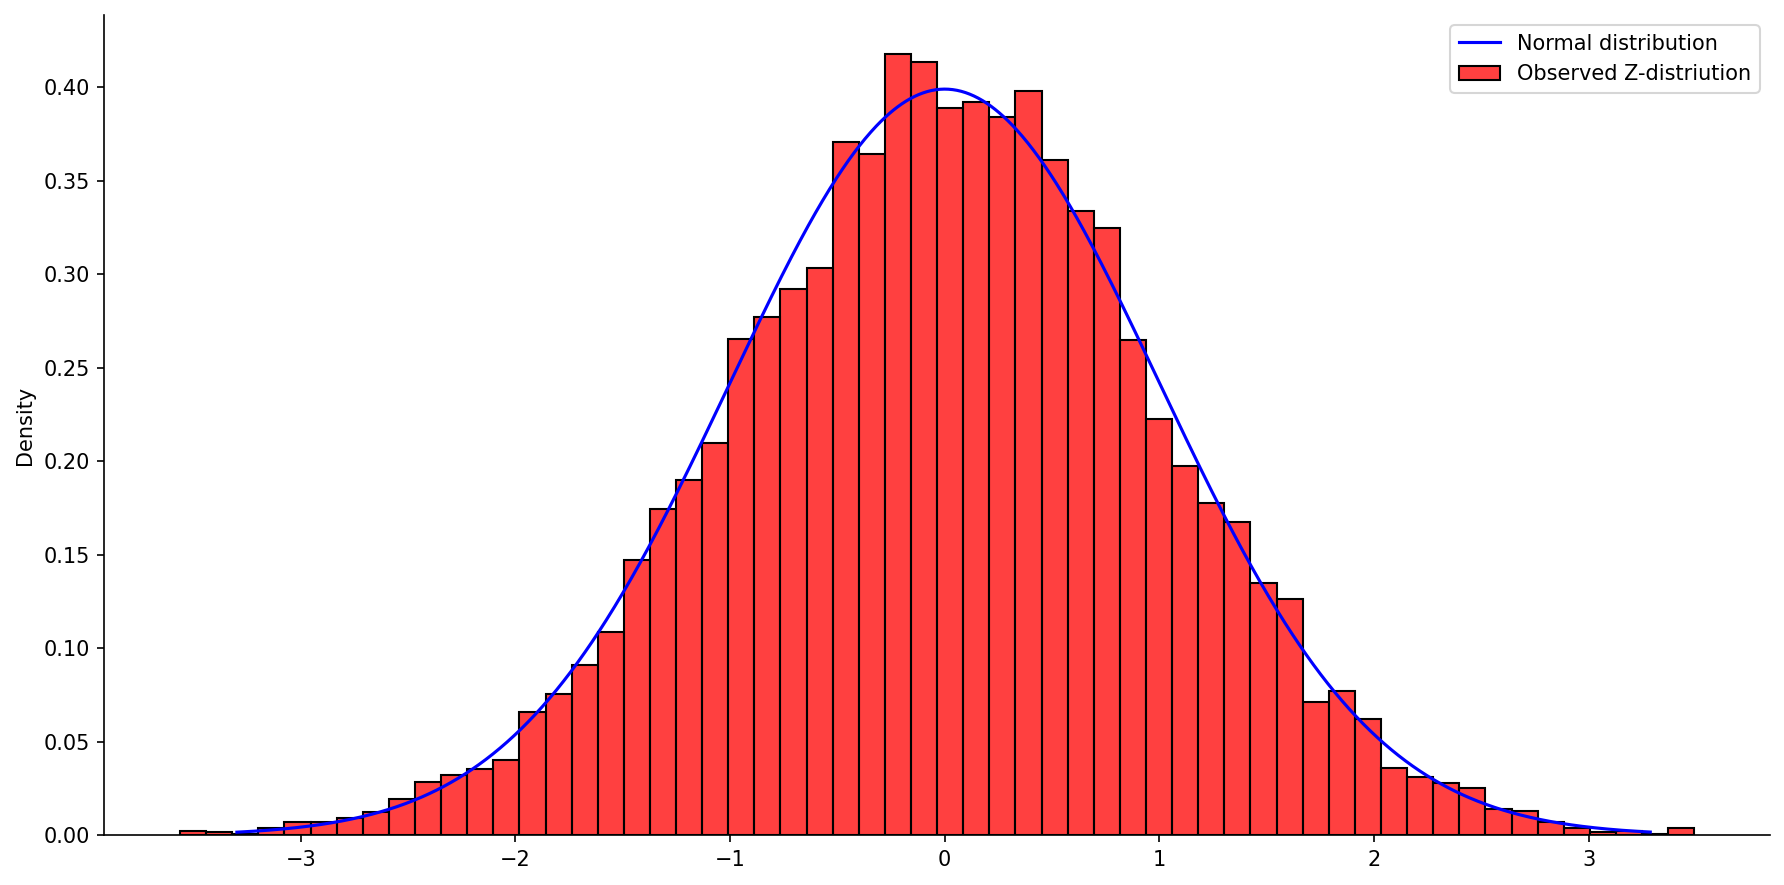

In [5]:
n_iter = 10000
n_sample = 7
sample_distribution = stats.norm(loc=5, scale=3)
t_func = lambda X: np.sqrt(len(X)) * (X.mean() - sample_distribution.mean()) / np.sqrt(X.var(ddof=1))
z_func = lambda X: np.sqrt(len(X)) * (X.mean() - sample_distribution.mean()) / np.sqrt(sample_distribution.var())

observed_t = stat_distribution(n_iter, t_func, n_sample, sample_distribution)
observed_z = stat_distribution(n_iter, z_func, n_sample, sample_distribution)

l_bound, r_bound = np.quantile(observed_t, [0.01, 0.99])
x = np.linspace(l_bound, r_bound, 1000)


sns.displot(observed_t, color='r', stat='density', label="Observed T-distriution", height=6, aspect=2)
plt.plot(x, stats.norm(loc=0, scale=1).pdf(x), color='b', label="Normal distribution")
plt.plot(x, stats.t(df=len(X)-1).pdf(x), color='g', label="Student distribution")

plt.legend()
plt.show()

sns.displot(observed_z, color='r', stat='density', label="Observed Z-distriution", height=6, aspect=2)
plt.plot(x, stats.norm(loc=0, scale=1).pdf(x), color='b', label="Normal distribution")

plt.legend()
plt.show()

Основная теорема:

Пусть $\xi \sim \mathcal{N}(0, 1), \eta \sim \chi^2_k$ и $\xi$ с $\eta$ независимы. Тогда статистика $\zeta = \dfrac{\xi}{\sqrt{\eta/k}} \sim t_{k}$

Мы можем сделать статиску Хи-квадрат из несмещенной дисперсии:     
$$\dfrac{(n - 1)\cdot S^2_X}{\sigma^2} = \underset{i=1}{\overset{n}{\sum}}\left(\xi_i - \overline \xi \right)^2 \sim \chi^2_{n-1}$$

- $\xi := \sqrt{n}\dfrac{\overline X - \mu_0}{\sigma} \sim \mathcal{N}(0, 1)$
- $\eta := \dfrac{(n - 1)\cdot S^2_X}{\sigma^2} \sim \chi^2_{n-1}$
- $\xi$ и $\eta$ [независимы](https://math.stackexchange.com/questions/4165803/overlinex-and-s2-are-independent)
- Тогда
    $$\begin{align}
        T = \sqrt{n}\dfrac{\overline X - \mu_0}{\sqrt{S^2}} = \frac{\sqrt{n}\dfrac{\overline X - \mu_0}{\sigma}}{\sqrt{\dfrac{(n - 1)\cdot S^2_X}{(n - 1)\sigma^2}}} = \dfrac{\xi}{\sqrt{\dfrac{\eta}{n-1}}} \sim t_{n - 1}
    \end{align}$$

In [6]:
# CI

###
#   (x.mean() - E(x)) / x.var() has a student distribution
#   We want CI for E(x)
#   So we just pass x.mean() and x.var() to the function
###

# Student
# SEM = Standard Error of Mean = sqrt(var / n)
ci_left, ci_right = stats.t.interval(confidence=0.95, loc=np.mean(X), df=len(X)-1, scale=stats.sem(X))

print(f"Student CI = [{ci_left:.1f},{ci_right:.1f}]")

# Normal
ci_left_z, ci_right_z = stats.norm.interval(confidence=0.95, loc=np.mean(X), scale=stats.sem(X))

print(f"Normal CI = [{ci_left:.1f}, {ci_right:.1f}]")

Student CI = [6.3,7.0]
Normal CI = [6.3, 7.0]


У t-test тяжелые хвосты => pvalue будет больше => Снижаем Type I Error

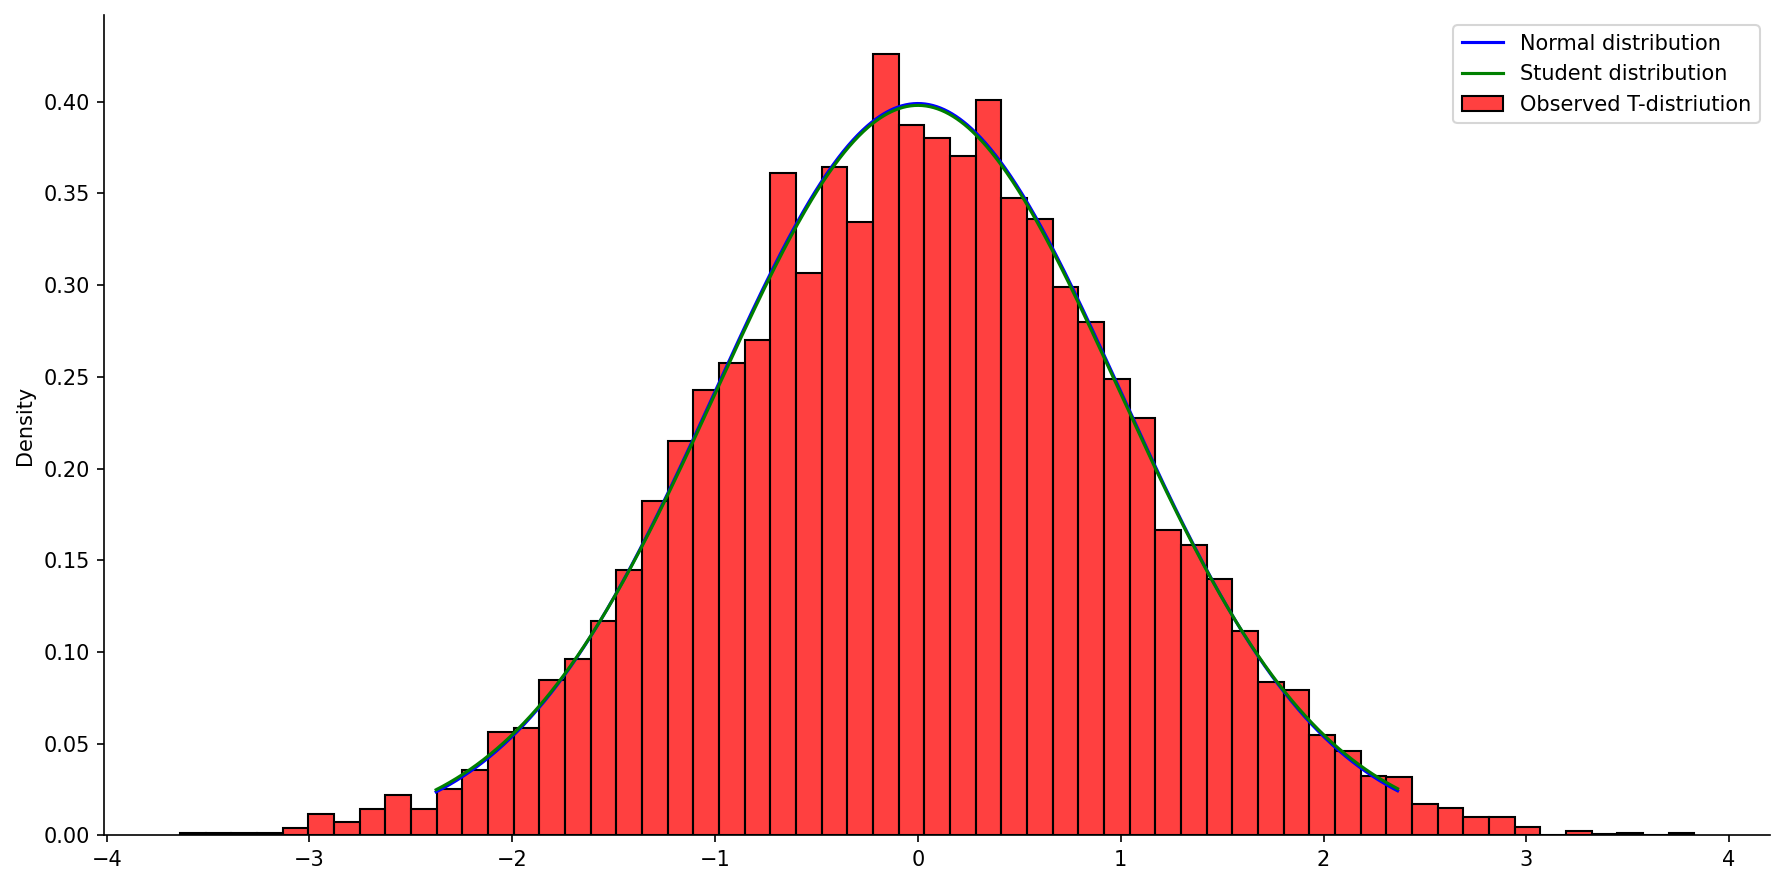

In [7]:
# Now we increase the sample size and see the approximation
# As we see, both student and normal distribution approximate almost identically

n_iter = 10000
n_sample = 100 # from 7 to 100
sample_distribution = stats.norm(loc=5, scale=3)
t_func = lambda X: np.sqrt(len(X)) * (X.mean() - sample_distribution.mean()) / np.sqrt(X.var(ddof=1))

observed_t = stat_distribution(n_iter, t_func, n_sample, sample_distribution)
observed_z = stat_distribution(n_iter, z_func, n_sample, sample_distribution)

l_bound, r_bound = np.quantile(observed_t, [0.01, 0.99])
x = np.linspace(l_bound, r_bound, 1000)


sns.displot(observed_t, color='r', stat='density', label="Observed T-distriution", height=6, aspect=2)
plt.plot(x, stats.norm(loc=0, scale=1).pdf(x), color='b', label="Normal distribution")
plt.plot(x, stats.t(df=n_sample-1).pdf(x), color='g', label="Student distribution")

plt.legend()
plt.show()

**Визуализируем, как найти MDE**

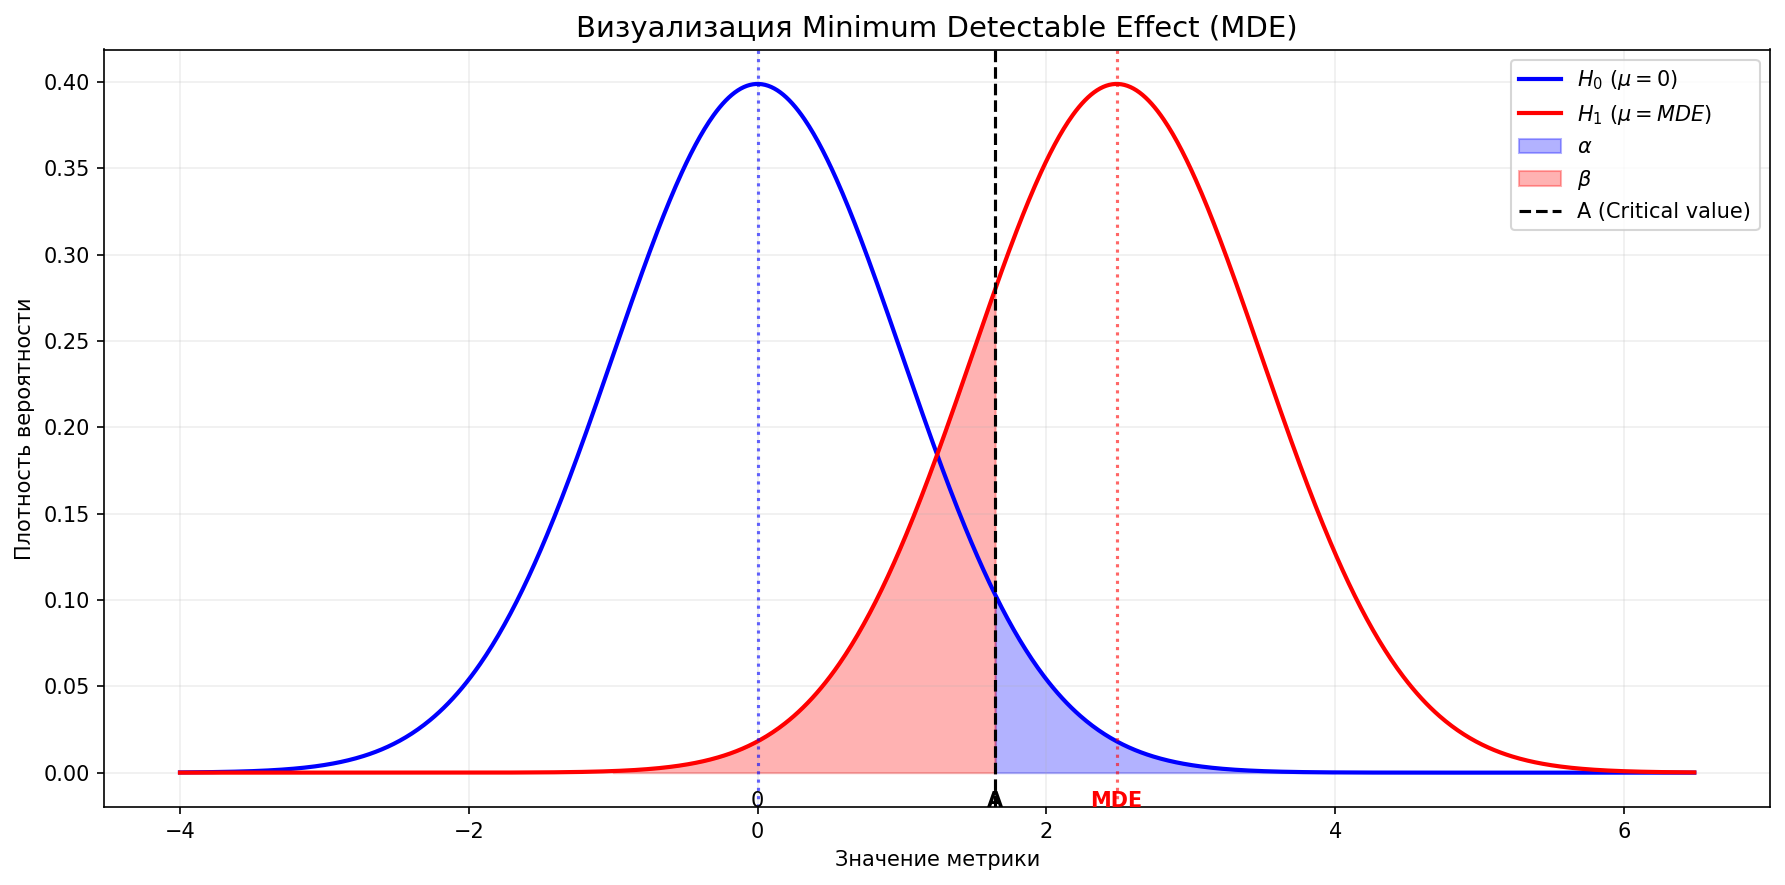

In [9]:
# Параметры для графика
alpha = 0.05
beta = 0.20
sigma_std = 1  # Стандартная ошибка (sigma/sqrt(n))

# Вычисляем квантили
z_alpha = stats.norm.ppf(1 - alpha)
z_beta = stats.norm.ppf(beta)
mde = (z_alpha - z_beta) * sigma_std # Т.к. z_beta отрицательный, это сумма модулей
a_crit = z_alpha * sigma_std

# Сетка значений x
x = np.linspace(-4 * sigma_std, mde + 4 * sigma_std, 1000)
y0 = stats.norm.pdf(x, 0, sigma_std)
y1 = stats.norm.pdf(x, mde, sigma_std)

# Рисуем
plt.figure(figsize=(12, 6))

# Кривые распределений
plt.plot(x, y0, label=r'$H_0$ ($\mu=0$)', color='blue', lw=2)
plt.plot(x, y1, label=r'$H_1$ ($\mu=MDE$)', color='red', lw=2)

# Заштриховываем Альфа (Ошибка I рода)
x_alpha = np.linspace(a_crit, 4 * sigma_std, 100)
plt.fill_between(x_alpha, stats.norm.pdf(x_alpha, 0, sigma_std), color='blue', alpha=0.3, label=r'$\alpha$')

# Заштриховываем Бета (Ошибка II рода)
x_beta = np.linspace(-1, a_crit, 100)
plt.fill_between(x_beta, stats.norm.pdf(x_beta, mde, sigma_std), color='red', alpha=0.3, label=r'$\beta$')

# Вертикальные линии для A и MDE
plt.axvline(a_crit, color='black', linestyle='--', label=f'A (Critical value)')
plt.axvline(mde, color='red', linestyle=':', alpha=0.6)
plt.axvline(0, color='blue', linestyle=':', alpha=0.6)

# Текстовые подписи
plt.text(a_crit, -0.02, 'A', ha='center', fontweight='bold')
plt.text(0, -0.02, '0', ha='center')
plt.text(mde, -0.02, 'MDE', ha='center', color='red', fontweight='bold')

# Оформление
plt.title(r'Визуализация Minimum Detectable Effect (MDE)', fontsize=14)
plt.xlabel('Значение метрики')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()


### Как вывести формулу для MDE. На самом деле делается достаточно несложно

Допустим A - это наша точка пресечения на графике 

1) При $H_0$:
$$ P(H_1 | H_0) = P(\xi > A | H_0) = P\left( \frac{\xi}{\sqrt{\sigma^2/n}} > \frac{A}{\sqrt{\sigma^2/n}} \right) = \alpha \implies A = z_{1-\alpha} \sqrt{\frac{\sigma^2}{n}}$$

2) При $H_1$:
$$P(H_0 | H_1) = P(\xi < A | H_1) = P\left( \frac{\xi - MDE}{\sqrt{\sigma^2/n}} < \frac{A - MDE}{\sqrt{\sigma^2/n}} \right) = \beta \implies A - MDE = z_{\beta} \sqrt{\frac{\sigma^2}{n}}$$

3) Итог:
$$MDE = (z_{1-\alpha} - z_{\beta}) \sqrt{\frac{\sigma^2}{n}} = (z_{1-\alpha} + z_{1-\beta}) \sqrt{\frac{\sigma^2}{n}}$$



In [10]:
# Считаем MDE 

profits = np.loadtxt('profit_from_user.out', delimiter=',')

n = 1000
sigma2 = profits.var()
alpha = 0.05
beta = 0.2

MDE = (stats.norm().ppf(1 - alpha) + stats.norm().ppf(1 - beta)) * np.sqrt(sigma2 / n)

print(f"MDE = {MDE:.1f}")

FileNotFoundError: profit_from_user.out not found.

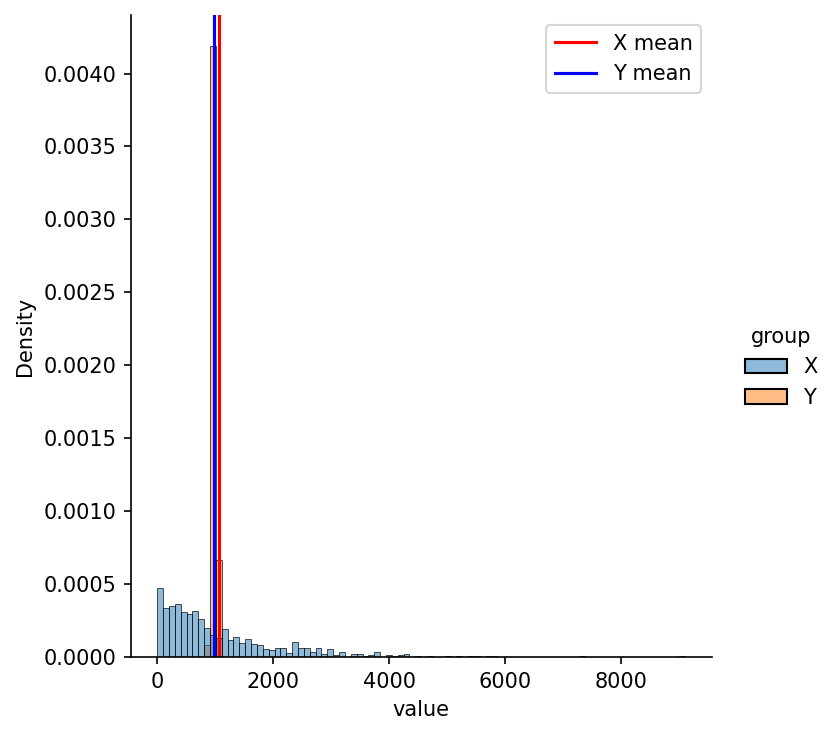

pvalue = 0.0
CI = [30.1, inf]


In [11]:
# Two Sample T-test

X = stats.expon(scale=1100).rvs(1000)
Y = stats.norm(loc=980, scale=30).rvs(1000)

df = pd.DataFrame({'value': np.concatenate([X, Y]), 'group': ['X']*len(X) + ['Y']*len(Y)})
sns.displot(data=df, x='value', hue='group', stat='density', alpha=0.5)
plt.axvline(X.mean(), color='r', label='X mean')
plt.axvline(Y.mean(), color='b', label='Y mean')
plt.legend()
plt.show()

# Independet two sample test X - Y

obj = stats.ttest_ind(X, Y, equal_var=False, alternative='greater')

CI_left, CI_right = obj.confidence_interval(confidence_level=0.95)

print(f"pvalue = {obj.pvalue:.1f}\nCI = [{CI_left:.1f}, {CI_right:.1f}]")